device: cuda
GPU Name: NVIDIA L40S
Allocated: 0.0 GB
Seed set to: 2026
sampled batch shape: (512, 1, 28, 28)
sampled labels shape: (512,)
clean baseline: {'t': -1, 'within_subset_rate': 1.0, 'mean_pred_confidence': 0.9990442991256714, 'mean_subset_probability': 0.9997940063476562}
identity [{'t': 0, 'within_subset_rate': 1.0, 'mean_pred_confidence': 0.999040424823761, 'mean_subset_probability': 0.9997901916503906}, {'t': 10, 'within_subset_rate': 1.0, 'mean_pred_confidence': 0.9991329908370972, 'mean_subset_probability': 0.9997825026512146}, {'t': 25, 'within_subset_rate': 1.0, 'mean_pred_confidence': 0.9991092681884766, 'mean_subset_probability': 0.9998512864112854}, {'t': 50, 'within_subset_rate': 1.0, 'mean_pred_confidence': 0.9988921284675598, 'mean_subset_probability': 0.9997926950454712}, {'t': 100, 'within_subset_rate': 1.0, 'mean_pred_confidence': 0.9974045157432556, 'mean_subset_probability': 0.9994193911552429}, {'t': 150, 'within_subset_rate': 0.998046875, 'mean_pred_confide

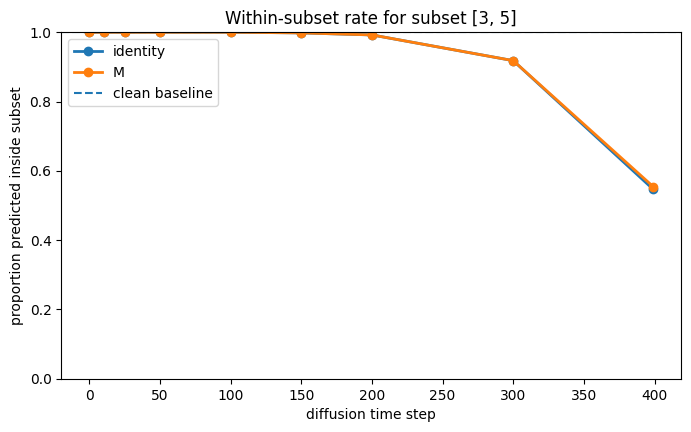

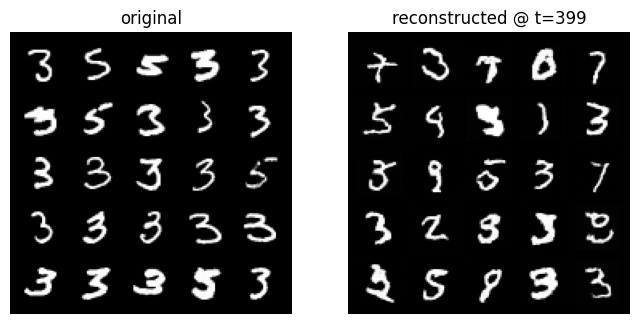

y_true: [3, 5, 5, 3, 3, 3, 5, 3, 3, 3, 3, 3, 3, 3, 5, 3, 3, 3, 3, 3, 3, 3, 3, 5, 3]
preds : [7, 3, 7, 0, 7, 5, 4, 3, 1, 3, 3, 9, 5, 3, 7, 3, 2, 3, 3, 3, 3, 5, 8, 3, 3]
conf  : [0.9998, 0.8854, 1.0, 0.9999, 1.0, 0.9994, 0.9501, 0.9968, 0.9999, 1.0, 0.9991, 0.9983, 1.0, 1.0, 0.9999, 1.0, 0.9996, 0.9912, 0.9984, 0.9998, 0.9417, 1.0, 0.9756, 0.9882, 1.0]
saved: fb_experiment_subset_3_5.pt


In [2]:
# File: 03_run_forward_backward_experiments.ipynb
# Paste each # %% cell into a notebook cell, or save as a .py script and run with cell support.

# %%
import torch

from common import device, print_device, set_seed
from ddpm_lib import load_ddpm_checkpoint
from classifier_lib import load_classifier_checkpoint
from experiment_lib import (
    sample_subset_batch,
    evaluate_clean_subset_rate,
    run_time_sweep_on_fixed_batch,
    plot_mode_comparison,
    show_reconstruction_examples,
)

print_device()

# %%
SEED = 2026
set_seed(SEED)

ROOT = "./data"
SPLIT = "test"                     # "train" or "test"
CLASS_SUBSET = {3, 5}
TIME_STEPS = [0, 10, 25, 50, 100, 150, 200, 300, 399]
N_SAMPLES = 512
BATCH_SIZE = 128

# t=-1 is reserved for the clean, no-diffusion baseline in the code below.
# t=0 here means the first DDPM forward step, consistent with the notebook indexing.

STORE_TIME_STEPS = [0, 50, 150, 399]
N_STORE = 25

CLF_CKPT_PATH = "classifier_01_norm.pt"

DDPM_CKPTS = {
    "identity": "ddpm_identity_T400.pt",
    "M": "ddpm_M_T400.pt",
}

MODES_TO_RUN = ["identity", "M"]   # choose one or both

# %%
clf_model, clf_cfg, _ = load_classifier_checkpoint(
    path=CLF_CKPT_PATH,
    device=device,
)

# %%
# Sample one fixed batch of clean images so every DDPM mode sees the same x0.
x_raw_batch, y_batch = sample_subset_batch(
    subset=CLASS_SUBSET,
    n_samples=N_SAMPLES,
    root=ROOT,
    split=SPLIT,
    seed=SEED,
    device=device,
)

print("sampled batch shape:", tuple(x_raw_batch.shape))
print("sampled labels shape:", tuple(y_batch.shape))

# %%
clean_baseline = evaluate_clean_subset_rate(
    clf_model=clf_model,
    clf_cfg=clf_cfg,
    x_raw_m11=x_raw_batch,
    subset=CLASS_SUBSET,
)
print("clean baseline:", clean_baseline)

# %%
all_runs = {}

for mode_name in MODES_TO_RUN:
    ddpm_model, precond, schedule, ckpt = load_ddpm_checkpoint(
        path=DDPM_CKPTS[mode_name],
        device=device,
    )

    out = run_time_sweep_on_fixed_batch(
        ddpm_model=ddpm_model,
        schedule=schedule,
        precond=precond,
        clf_model=clf_model,
        clf_cfg=clf_cfg,
        x_raw_m11=x_raw_batch,
        y_true=y_batch,
        subset=CLASS_SUBSET,
        time_steps=TIME_STEPS,
        batch_size=BATCH_SIZE,
        forward_seed_base=1000,
        reverse_seed_base=2000,
        store_time_steps=STORE_TIME_STEPS,
        n_store=N_STORE,
    )

    all_runs[mode_name] = out
    print(mode_name, out["results"])

# %%
plot_mode_comparison(
    results_by_name={k: v["results"] for k, v in all_runs.items()},
    subset=CLASS_SUBSET,
    as_bar=False,
    baseline=clean_baseline,
)

# %%
# Optional: inspect reconstructions for one mode and one t
MODE_TO_VIEW = MODES_TO_RUN[-1]
TIME_TO_VIEW = STORE_TIME_STEPS[-1]

show_reconstruction_examples(
    experiment_output=all_runs[MODE_TO_VIEW],
    t=TIME_TO_VIEW,
    nrow=5,
)

# %%
# Save the experiment outputs for later analysis
save_obj = {
    "subset": sorted(list(CLASS_SUBSET)),
    "split": SPLIT,
    "time_steps": TIME_STEPS,
    "clean_baseline": clean_baseline,
    "runs": all_runs,
}

SAVE_PATH = f"fb_experiment_subset_{'_'.join(map(str, sorted(list(CLASS_SUBSET))))}.pt"
torch.save(save_obj, SAVE_PATH)
print("saved:", SAVE_PATH)

In [ ]:
# CHeck to make such whatever M we use is accesiable 

# import torch
# M = torch.load("M_784.pt", map_location="cpu")
# M.shape

torch.Size([784, 784])